In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MANUSCRIPT_FIG_DIR = Path("/Users/hdong/Projects/VoxSolaris_Article/figs")
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
})


from pv_analysis_re import (
    SiteConfig,
    find_clear_days,
    load_and_smooth_shadow_matrix,
    load_extra_data_csv,
    load_inverter_data,
    pv_analysis,
    compute_metrics,
    evaluate_performance,
    print_performance_summary,
    plot_real_vs_predicted_scatter,
    save_all_day_plots,
    calculate_api_grid,
    plot_api_map,
)

# Project modules (unchanged)
from shadow_matrix_simulation_re import create_shadow_matrix
# from plot_radiation_day import plot_radiation_day
# from batch_day_plots import batch_radiation_plots, batch_day_plots
try:
    from visual_utils import plot_shadow_matrix_with_sunpaths
except ImportError:
    plot_shadow_matrix_with_sunpaths = None

In [2]:
cfg = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=12.0,
    azimuth_deg=170.0,
    nominal_power_kw=3.96,  # 15% derating for system losses (cabling, inverter inefficiency, etc.)
    system_efficiency=0.8,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,  # Fronius Symo logs in fixed UTC+3
    forecast_shift_minutes=-30, # Shift forecasts 30 minutes earlier to better align with measured data
    window_size=(3, 3),
    interval="5min",
    interval_minutes=5.0,
)

# --- File Paths ---
RAD_FILE       = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_rad.csv"
TEMP_WIND_FILE = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_temp_wind.csv"
CLEAR_MINUTES  = "data/Clear_sky_minutes_kuopio_RH16.txt"
PV_EXCEL       = "data/pvdata/pv_21.xlsx"

LIDAR_FILE     = "output/reclassified_final_v5.laz"
SHADOW_DIR     = "results/shadow_matrix_results_SE_pro"
SHADOW_FN      = "shadow_attenuation_matrix_conecasting_SE_v10.csv"
SHADOW_CSV     = f"{SHADOW_DIR}/{SHADOW_FN}"
EXTRA_DATA_DIR = "output"

In [3]:
# %% --- 3. Create Shadow Matrix (ray-tracing — slow, run once) ---
# Uncomment to regenerate:
# shadow_matrix_raw = create_shadow_matrix(
#     lidar_file_path=LIDAR_FILE, voxel_size=2.0,
#     output_dir=SHADOW_DIR, output_fn=SHADOW_FN,
#     offset_from_roof=-0.5, skip_dist=3.0,
# )


# %% --- 4. Load & Pre-smooth Shadow Matrix (done ONCE) ---
shadow_matrix = load_and_smooth_shadow_matrix(SHADOW_CSV, window_size=cfg.window_size)
print(f"Shadow matrix shape: {shadow_matrix.shape}  (altitude x azimuth)")

Shadow matrix shape: (91, 361)  (altitude x azimuth)


In [4]:
# %% --- 6. Load Inverter Data ---
pv_df = load_inverter_data(PV_EXCEL, expected_interval_min=cfg.interval_minutes)
print(f"Range: {pv_df['Timestamp'].min()} -> {pv_df['Timestamp'].max()}")
print(pv_df.head())

Inverter data: 102,263 records, 102235/102262 normal intervals, 27 gaps
  Largest gaps: [965. 925. 905. 875. 825.] min
Range: 2021-01-01 00:00:00 -> 2021-12-31 23:55:00
            Timestamp  Energy_Wh  Power_W
0 2021-01-01 00:00:00        0.0      0.0
1 2021-01-01 00:05:00        0.0      0.0
2 2021-01-01 00:10:00        0.0      0.0
3 2021-01-01 00:15:00        0.0      0.0
4 2021-01-01 00:20:00        0.0      0.0


Evaluating 153 days: 2021-05-01 → 2021-09-30


All days: 100%|██████████| 153/153 [00:04<00:00, 35.45it/s]


Per-day results saved to: results/all_days_metrics_b1.csv

  OVERALL METRICS — 2021-05-01 to 2021-09-30
  153 days evaluated, 0 skipped, 27240 daytime samples

  Metric                   Baseline  Shadow-Corr  Improvement
  --------------------------------------------------------
  RMSE (W)                    540.0        413.1        23.5%
  MAE (W)                     353.0        245.9        30.4%
  MBE (W)                     201.7        -47.6       closer
  R²                          0.432        0.667       +0.236

  Energy (kWh)             Real       Base  Corrected
  ------------------------------------------------
  Total                  1613.8     2077.6     1508.5
  Error                             +28.7%      -6.5%

  Per-day averages (mean of 153 daily metrics):
  RMSE      Base: 496.9 ± 209.4   Corr: 376.6 ± 157.3
  MAE       Base: 349.1 ± 162.1   Corr: 242.3 ± 92.6
  MBE       Base: 201.5 ± 182.3   Corr: -43.4 ± 111.7
  R²        Base: -0.078 ± 1.108   Corr: 0.366 

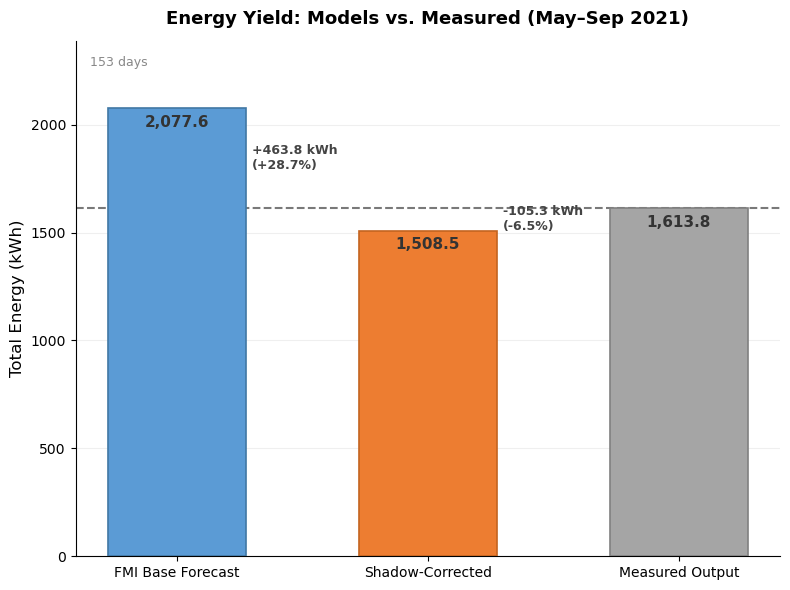

Saved: /Users/hdong/Projects/VoxSolaris_Article/figs/b1_fullperiod_rmse.png


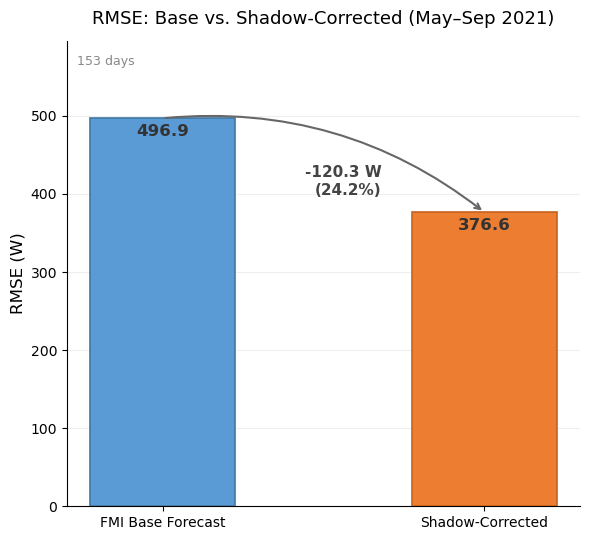

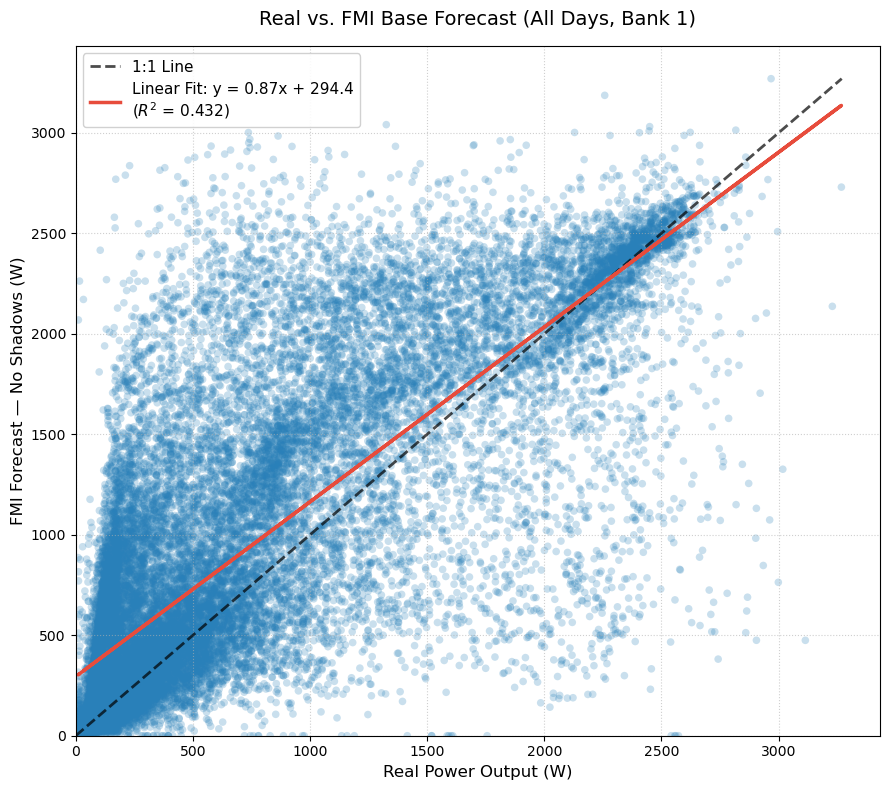

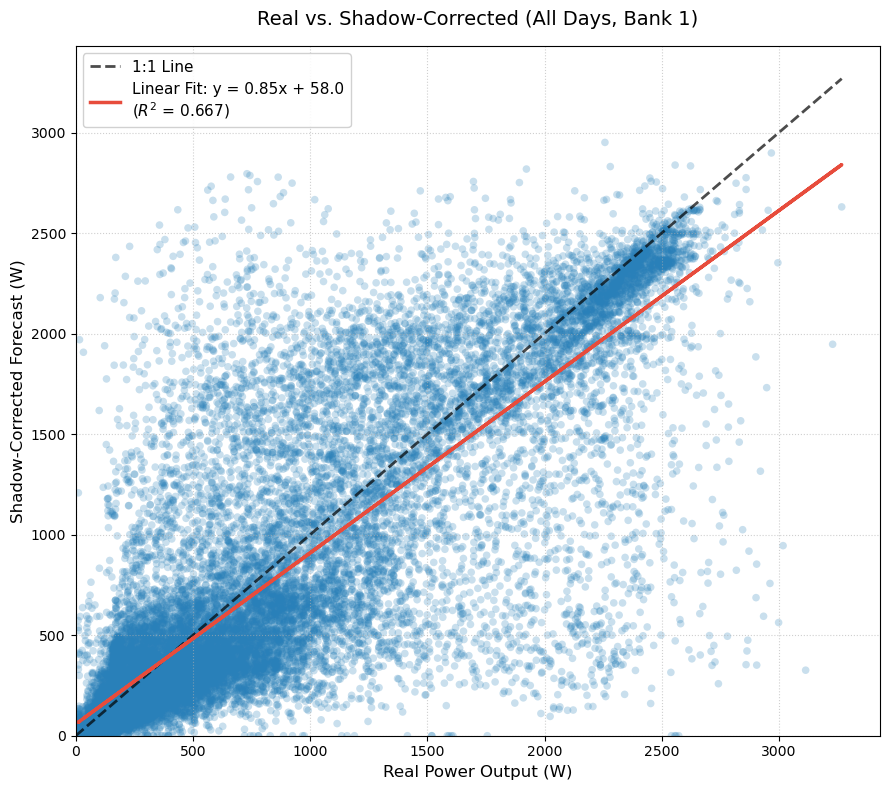

In [5]:
# %% --- Build extra_data from FMI CSVs ---
from build_extra_data import build_all_extra_data, make_extra_data_loader

RAD_CSV = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_rad.csv"
TW_CSV  = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_temp_wind.csv"
LAT, LON = 62.8924, 27.6353

# Build all extra_data CSVs (run once, then skip)
# build_all_extra_data(
#     rad_csv=RAD_CSV, temp_wind_csv=TW_CSV,
#     latitude=LAT, longitude=LON,
#     output_dir="output",
#     start_date="2021-05-01", end_date="2021-09-30",
# )

# Create loader for evaluate functions
extra_loader = make_extra_data_loader(
    rad_csv=RAD_CSV, temp_wind_csv=TW_CSV,
    latitude=LAT, longitude=LON,
)

# %% --- Evaluate selected clear days (20 days) ---
# results_df, all_real, all_pred = evaluate_performance(
#     significant_days_df=clear_days,
#     shadow_matrix=shadow_matrix,
#     excel_df=excel_df,
#     extra_data_loader=extra_loader,
#     cfg=cfg,
# )
# print_performance_summary(results_df)

# %% --- Evaluate ALL days May–September ---
from evaluate_all_days import evaluate_all_days, plot_energy_bar_chart, _plot_metric_comparison

all_results, all_real, all_base, all_shad = evaluate_all_days(
    start_date="2021-05-01",
    end_date="2021-09-30",
    shadow_matrix=shadow_matrix,
    excel_df=pv_df,
    extra_data_loader=extra_loader,
    cfg=cfg,
    output_csv="results/all_days_metrics_b1.csv",
)

plot_energy_bar_chart(
    all_results,
    title_suffix="May–Sep 2021",
    save_path=str(MANUSCRIPT_FIG_DIR / "b1_fullperiod_energy.png"),
)
_plot_metric_comparison(
    all_results["RMSE_Base"].mean(),
    all_results["RMSE_Shaded"].mean(),
    "RMSE",
    "W",
    n_days=len(all_results),
    title_suffix="May–Sep 2021",
    save_path=str(MANUSCRIPT_FIG_DIR / "b1_fullperiod_rmse.png"),
)
if all_real:
    plot_real_vs_predicted_scatter(
        all_real, all_base,
        title="Real vs. FMI Base Forecast (All Days, Bank 1)",
        ylabel="FMI Forecast — No Shadows (W)",
        power_threshold=0.0,
        save_path=str(MANUSCRIPT_FIG_DIR / "b1_fullperiod_scatter_base.png"),
    )
    plot_real_vs_predicted_scatter(
        all_real, all_shad,
        title="Real vs. Shadow-Corrected (All Days, Bank 1)",
        ylabel="Shadow-Corrected Forecast (W)",
        power_threshold=0.0,
        save_path=str(MANUSCRIPT_FIG_DIR / "b1_fullperiod_scatter_corr.png"),
    )
